<div style="display: flex; align-items: center; justify-content: center; flex-wrap: wrap;">
    <div style="flex: 1; max-width: 400px; display: flex; justify-content: center;">
        <img src="https://magic.novaims.unl.pt/media/1tdf2arr/ims25_horizontal__positivo_rgb.svg" style="max-width: 70%; height: auto; margin-top: 50px; margin-bottom: 50px;margin-left: 6rem;">
    </div>
    <div style="flex: 2; text-align: center; margin-top: 20px;margin-left: 6rem;">
        <div style="font-size: 28px; font-weight: bold; line-height: 1.2;">
            <span style="color: #FFCD41;">Thesis Project |</span> <span style="color: #F58228;">LLM-Powered Urban Exploration: A Framework for Adaptive Tourist and Mobility Route Planning</span>
        </div>
        <div style="font-size: 17px; font-weight: bold; margin-top: 10px;">
            2025 - 2026
        </div>
        <div style="font-size: 17px; font-weight: bold;">
            Master in Data Science and Advanced Analytics
        </div>
        <div style="margin-top: 20px;">
            <div>André Filipe Gomes Silvestre, 20240502</div>
        </div>
    </div>
</div>

<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: linear-gradient(to right, #F58228, #FFCD41);
            padding: 15px; color: white; border-radius: 300px; text-align: center;">
    <center><h1 style="margin-left: 100px;margin-top: 10px; margin-bottom: 4px; color: white;
                       font-size: 32px; font-family: 'Avenir Next LT Pro', sans-serif;"><b>1 & 2 | Business & Data Understanding</b></h1></center>
</div>

<br><br>


## **📝 Notebook Overview**

This notebook analyzes datasets scraped from the **VisitLisbon** and **Dados.gov** websites. It includes data cleaning, exploratory data analysis (EDA), and visualizations to uncover insights about tourist attractions and public amenities in Lisbon.

<br><br>

In [68]:
# Install the required packages
# !pip install json pandas matplotlib seaborn


In [69]:
# Import necessary libraries
import re
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

%matplotlib inline

In [70]:
# Settings to customize plots
sns.set_theme(context='paper', style="white", font= 'Borna', rc={"figure.figsize":(48, 32)}, font_scale=1.5)

# Define a color palette based on the project colors (Orange/Yellow tones)
# #ff4011 (Red), #F58228 (Orange), #f6da00 (Yellow)
custom_palette = ['#ff4011', '#F58228', '#f6da00']
sns.set_palette(custom_palette)


In [71]:
# Load the JSON files
with open('events.json', 'r', encoding='utf-8') as f:
    events_data = json.load(f)

with open('places.json', 'r', encoding='utf-8') as f:
    places_data = json.load(f)

with open('lisbon_datasets.json', 'r', encoding='utf-8') as f:
    lisbon_datasets = json.load(f)

## <span style="color: #ffffff;">Dados Abertos Lisboa Analysis</span>
<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: transparent;
            padding: 10px; color: white; border-radius: 300px; text-align: center;
            border: 2px solid #F58228;">
    <center><h2 style="margin-left: 120px;margin-top: 10px; margin-bottom: 4px; color: #F58228;
                       font-size: 24px; font-family: 'Avenir Next LT Pro', sans-serif;"><b> Dados Abertos Lisboa Analysis</b></h2></center>
</div>

<br><br>

This section analyzes the datasets scraped from the **[Dados Abertos Lisboa](https://dados.gov.pt/pt/datasets/?geozone=pt%3Aconcelho%3A1106)** portal.

### **🔎 Dataset Attributes**

<center><b>Table 1 | </b> Dataset Attributes with Descriptions (Dados.gov). <br>

<br>

|       | **Field**                          | **Description**                                                                 | **Type**     |
|:-----:|:----------------------------------:|---------------------------------------------------------------------------------|:------------:|
| **1** | `title`                            | Title of the dataset                                                             | **`Text`**         |
| **2** | `url_portal`                       | URL of the dataset on the portal                                                 | **`Text`**         |
| **3** | `stable_url`                       | Stable or permanent URL of the dataset                                           | **`Text`**         |
| **4** | `description`                      | Description of the dataset                                                      | **`Text`**         |
| **5** | `file_formats`                     | Available file formats for the dataset (e.g., CSV, JSON, XML)                   | **`Text/List`**    |

</center>

In [72]:
# Create a DataFrame for Lisbon Open Data
df_lisbon = pd.DataFrame(lisbon_datasets)

# Display the first few rows
df_lisbon.head()

,title,url_portal,stable_url,description,file_formats,last_updated
0,Atlas Digital (Atlas Digital)Atlas Digital,https://dados.gov.pt/pt/datasets/atlas-digital/,https://dados.gov.pt/pt/datasets/r/28d9ca5b-ae...,O Atlas Digital da Área Metropolitana de Lisbo...,"html, pdf",2025-08-07T09:01:32.224000
1,Plano Metropolitano de Adaptação às Alterações...,https://dados.gov.pt/pt/datasets/plano-metropo...,https://dados.gov.pt/pt/datasets/r/4c7ea8af-f4...,O Plano Metropolitano de Adaptação às Alteraçõ...,"pdf, wms",2025-08-07T09:02:54.011000
2,Rede de monitorização e de alerta meteorológic...,https://dados.gov.pt/pt/datasets/rede-de-monit...,https://dados.gov.pt/pt/datasets/r/28365431-8e...,O projeto CLIMA.AML tem como objetivo a criaçã...,"html, xml",2025-07-31T10:00:05.407000
3,Pontos de Interesse Climate Walks,https://dados.gov.pt/pt/datasets/pontos-de-int...,https://dados.gov.pt/pt/datasets/r/c4f494b7-d8...,"Indicação do arvoredo, elementos de água, corr...",geojson,2025-06-06T00:00:00
4,Percursos Climate Walks,https://dados.gov.pt/pt/datasets/percursos-cli...,https://dados.gov.pt/pt/datasets/r/06ee59fa-7d...,"Indicação do arvoredo, elementos de água, corr...",geojson,2025-06-06T00:00:00


In [73]:
# Basic information about the dataset
print(f"Total number of datasets: {len(df_lisbon)}")
print("\nData Types:")
pd.DataFrame(df_lisbon.dtypes, columns=['Data Type'])

Total number of datasets: 310

Data Types:


,Data Type
title,object
url_portal,object
stable_url,object
description,object
file_formats,object
last_updated,object


In [74]:
print("\nMissing Values:")
pd.DataFrame(df_lisbon.isnull().sum(), columns=['Missing Values'])


Missing Values:


,Missing Values
title,0
url_portal,0
stable_url,0
description,0
file_formats,0
last_updated,0


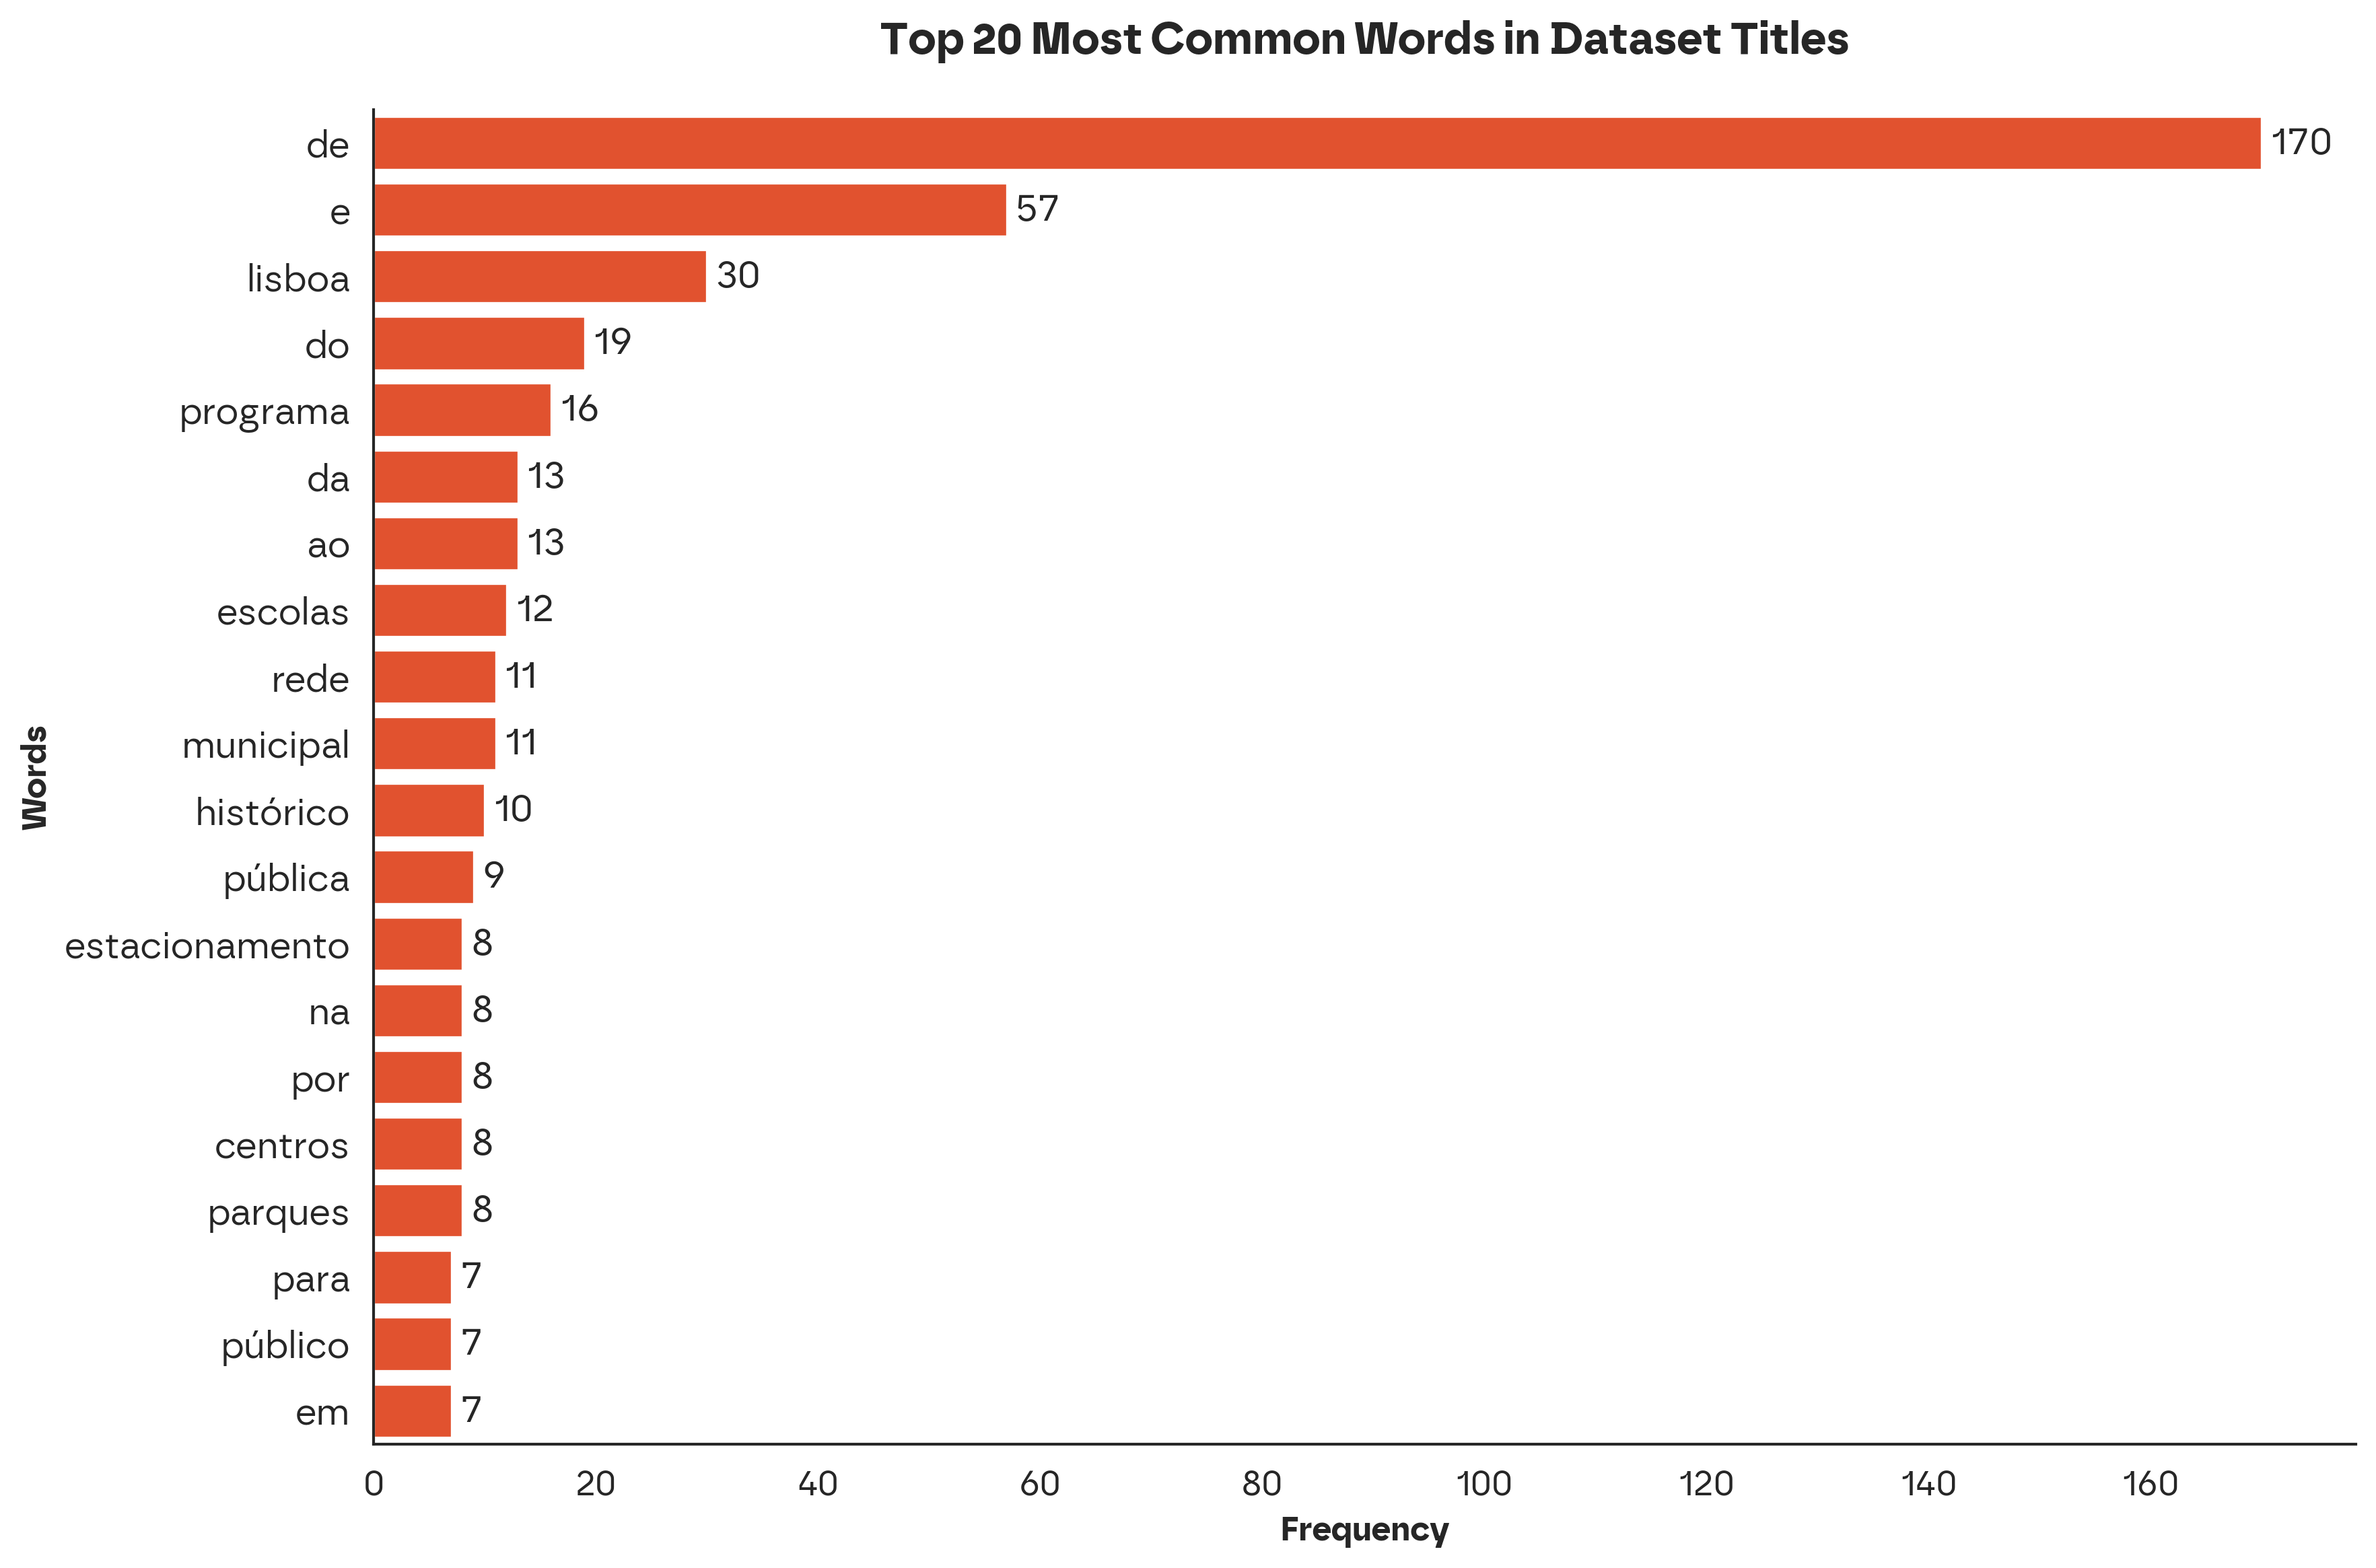

Top 20 most common words in titles:


,Count
Word,
de,170
e,57
lisboa,30
do,19
programa,16
da,13
ao,13
escolas,12
rede,11


In [75]:
# Function to clean and tokenize text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

# Analyze titles
all_titles = " ".join(df_lisbon['title'].astype(str))
title_words = clean_text(all_titles)
title_word_counts = Counter(title_words)

# Prepare data for plotting
top_words_df = pd.DataFrame(title_word_counts.most_common(20), columns=['Word', 'Count'])

# Plot Top 20 Most Common Words
plt.figure(figsize=(12, 8), dpi=300)
ax = sns.barplot(data=top_words_df, x='Count', y='Word', color=custom_palette[0])

# Customization
ax.set_title('Top 20 Most Common Words in Dataset Titles', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_ylabel('Words', fontsize=12, fontweight='bold')
sns.despine(top=True, right=True)

# Add value labels to the bars
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.tight_layout()
plt.show()

# Display top 20 most common words in titles
print("Top 20 most common words in titles:")
pd.DataFrame(title_word_counts.most_common(20), columns=['Word', 'Count']).set_index('Word')


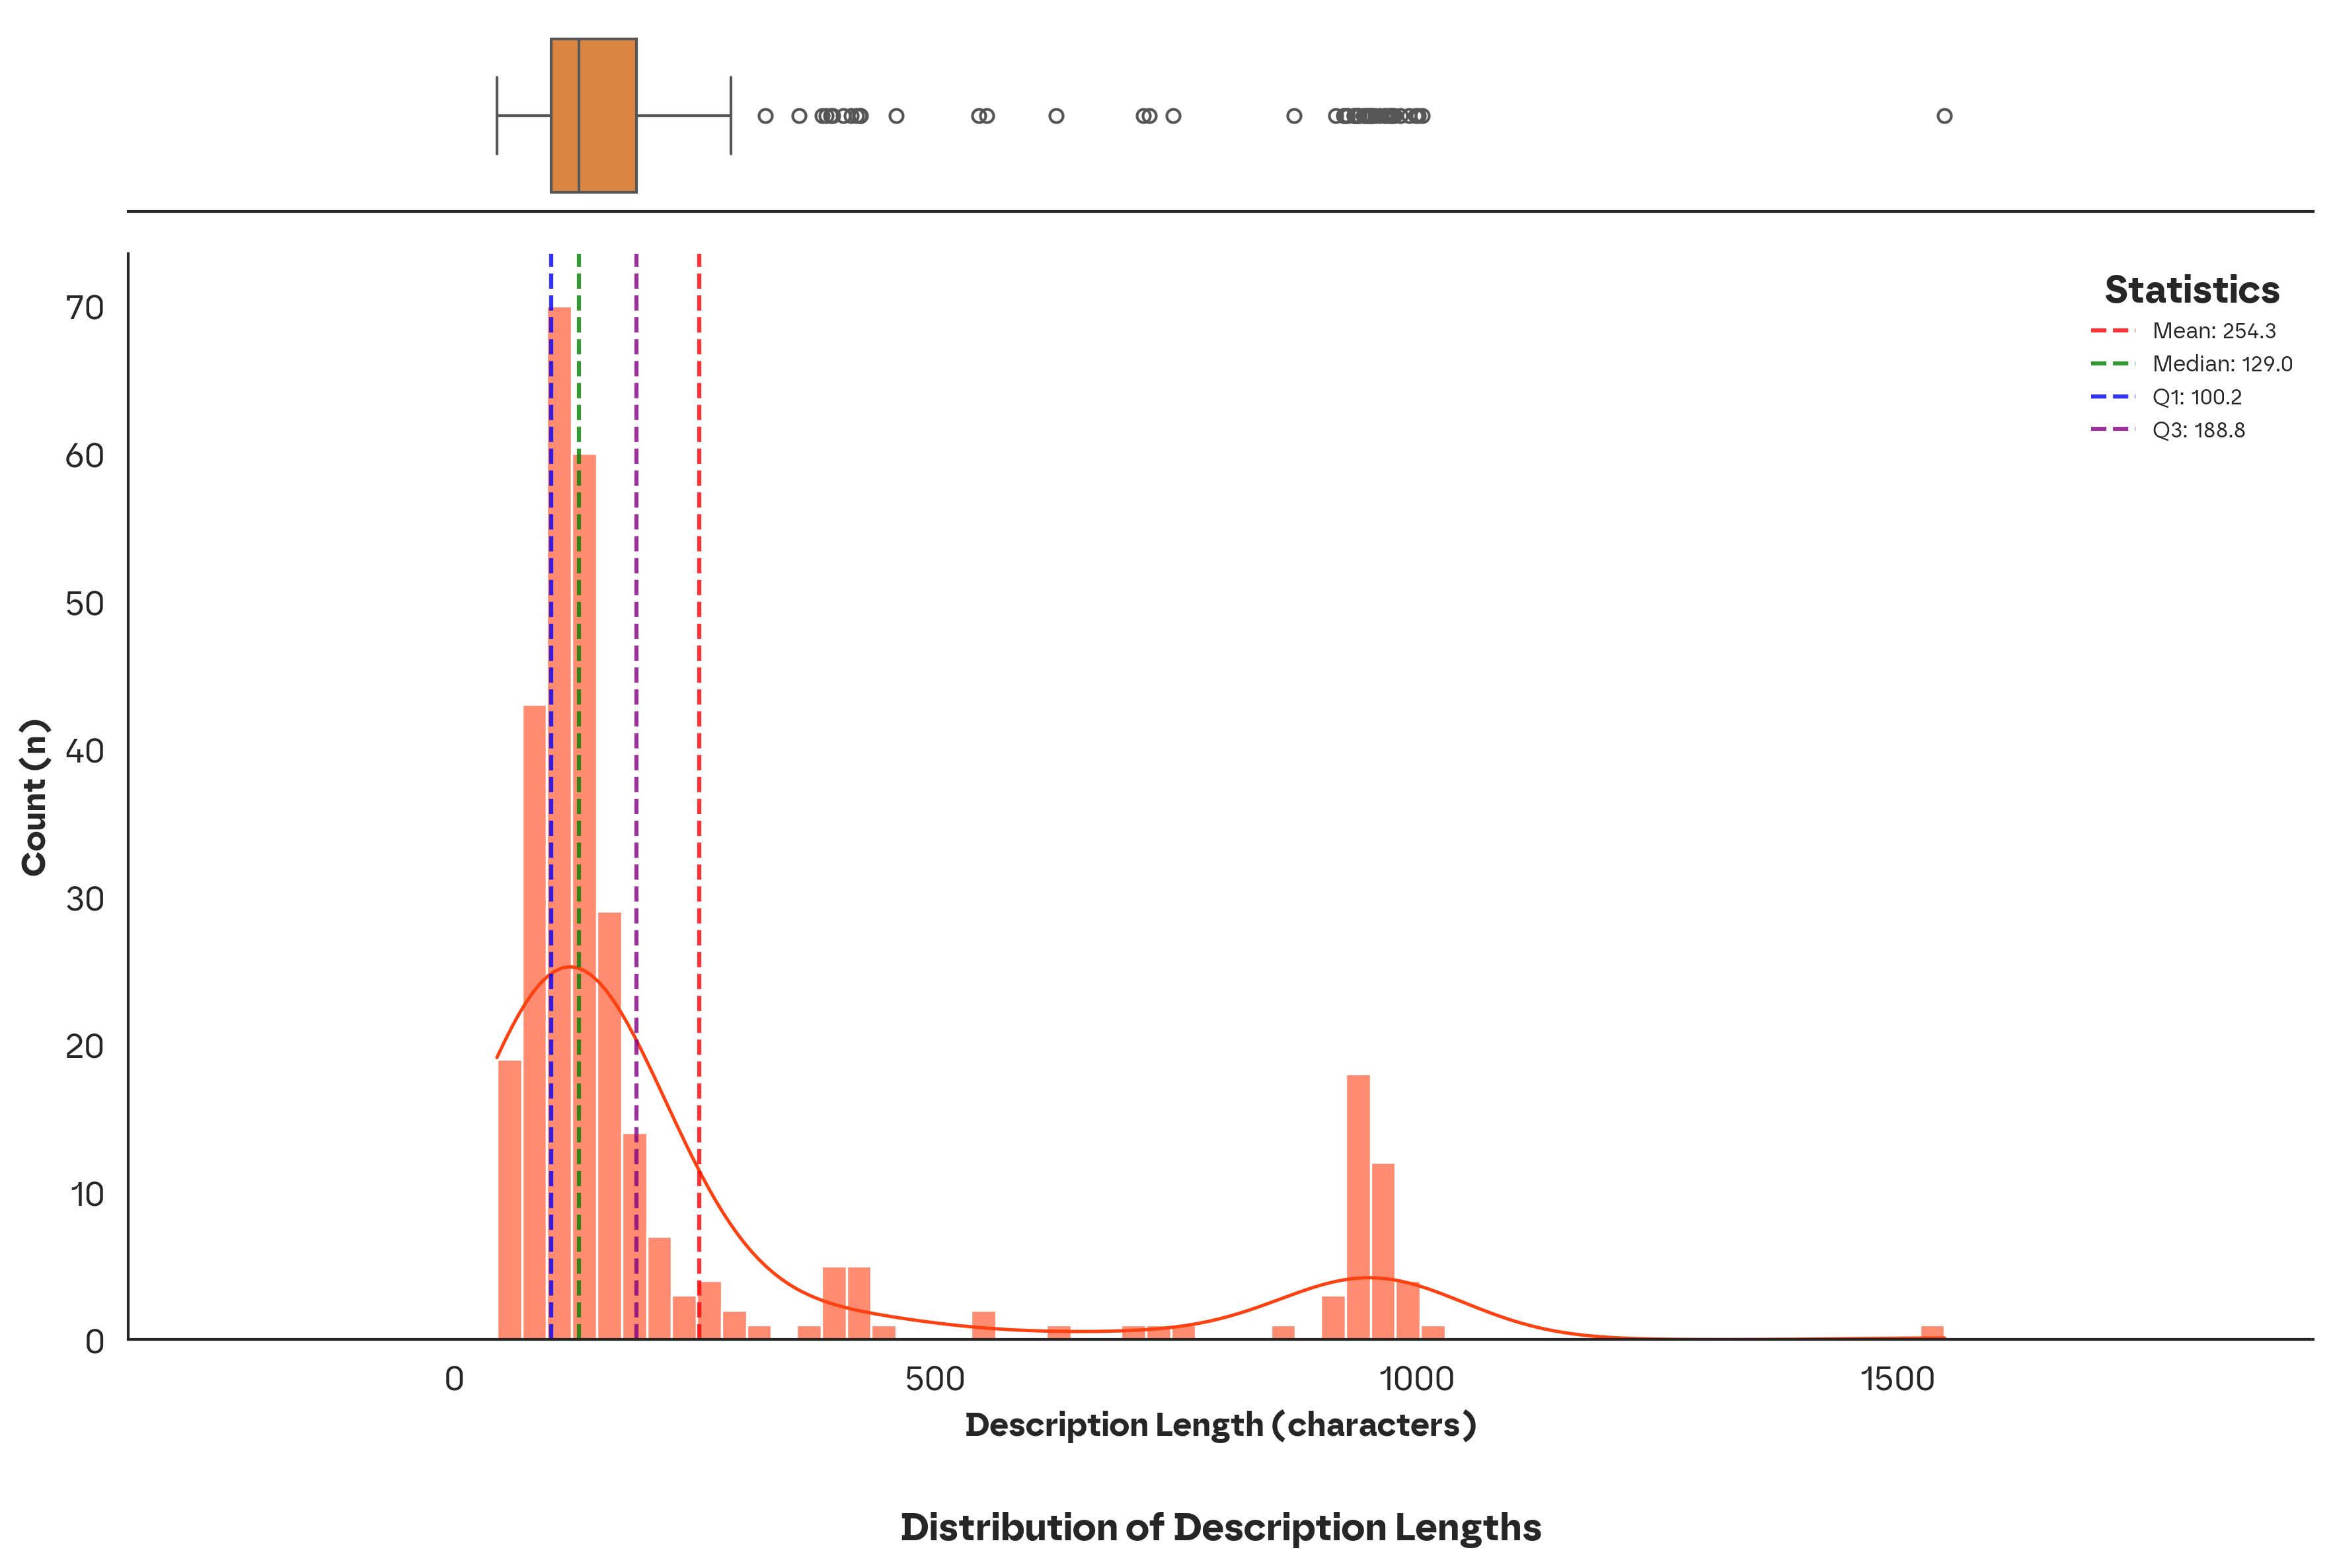

Datasets with the longest descriptions:


,title,description_length
2,Rede de monitorização e de alerta meteorológic...,1549
272,Comercialização de Hardware e Software e Serviços,1006
295,"Artes Performativas - Teatro, Dança e Música",1002
256,Ensino de Atividades Criativas e Culturais,999
260,"Edição (Livros, Jornais e Revistas)",992


In [76]:
# Analyze description length
df_lisbon['description_length'] = df_lisbon['description'].astype(str).apply(len)

# Prepare figure for Histogram & Boxplot
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(12, 8), dpi=300,
                                      sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

# Plot the Boxplot on the top
sns.boxplot(x=df_lisbon['description_length'], color=custom_palette[1], ax=ax_box)

# Plot the Histogram and the KDE on the bottom
sns.histplot(df_lisbon['description_length'], color=custom_palette[0], kde=True, stat='count', alpha=0.6, ax=ax_hist)
sns.kdeplot(df_lisbon['description_length'], color=custom_palette[0], lw=1, warn_singular=False, ax=ax_hist)

# Add mean, median and percentiles to the plot
mean_val = df_lisbon['description_length'].mean()
median_val = df_lisbon['description_length'].median()
q1_val = df_lisbon['description_length'].quantile(0.25)
q3_val = df_lisbon['description_length'].quantile(0.75)

ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Mean: {mean_val:.1f}')
ax_hist.axvline(median_val, color='green', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Median: {median_val:.1f}')
ax_hist.axvline(q1_val, color='blue', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Q1: {q1_val:.1f}')
ax_hist.axvline(q3_val, color='purple', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Q3: {q3_val:.1f}')

# Add a legend to the histogram
ax_hist.legend(loc='best', title='Statistics', title_fontproperties={'weight':'bold', 'size':'14'}, fontsize=8, frameon=False)

# Customizing the titles and labels
ax_box.set(xlabel='')
ax_hist.set_title('Distribution of Description Lengths', y=-0.2, fontweight='bold', fontsize=14)
ax_hist.set_xlabel('Description Length (characters)', fontsize=12, fontweight='bold')
ax_hist.set_ylabel('Count (n)', fontsize=12, fontweight='bold')

# Remove spines
sns.despine(ax=ax_box, left=True)
sns.despine(ax=ax_hist)
plt.tight_layout()
plt.show()

# Show datasets with the longest descriptions
print("Datasets with the longest descriptions:")
df_lisbon.nlargest(5, 'description_length')[['title', 'description_length']]

In [77]:
# Analyze file formats
all_formats = df_lisbon['file_formats'].dropna().explode()
format_counts = all_formats.value_counts()

# DataFrame with 'n' and '%'
format_df = pd.DataFrame({
    'n': format_counts,
    '%': (format_counts / len(df_lisbon) * 100).round(2)
})
format_df

,n,%
file_formats,,
geojson,179,57.74
xlsx,43,13.87
"geojson, json-ld",16,5.16
xls,7,2.26
geojason,6,1.94
csv,5,1.61
"csv, xlsx",5,1.61
shp,5,1.61
zip,4,1.29


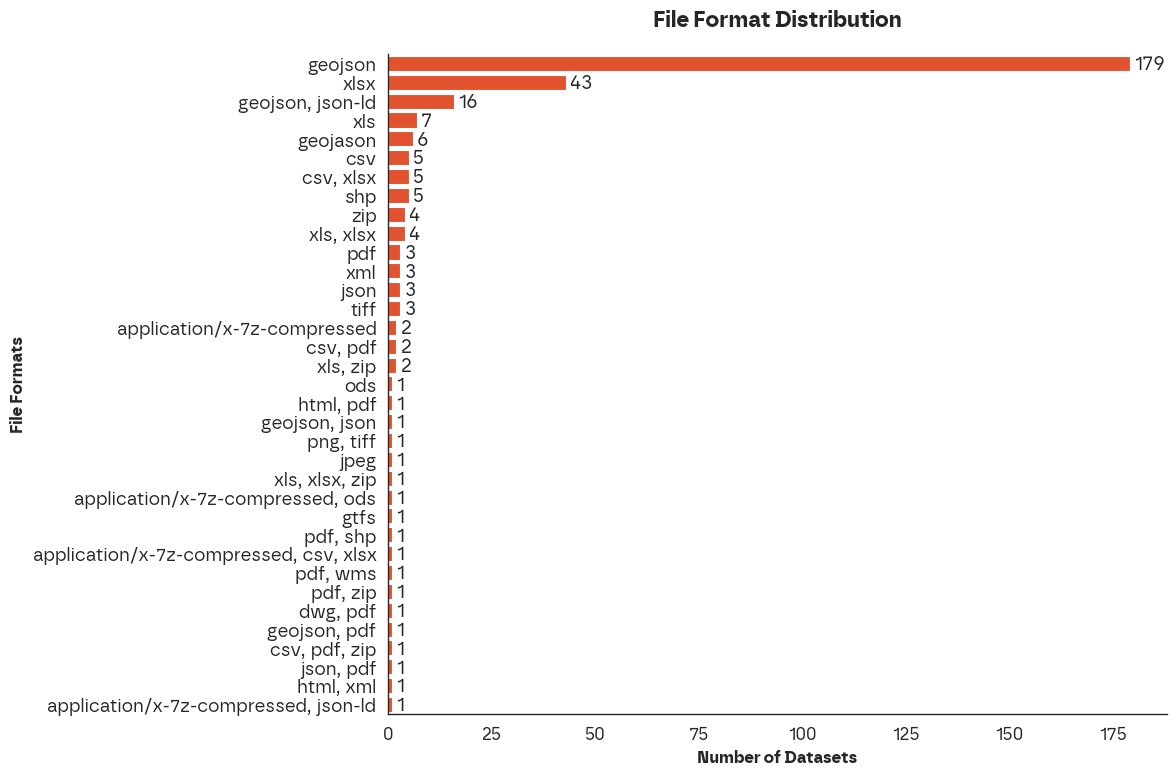

In [78]:

# Plot File Format Distribution
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=format_counts.values, y=format_counts.index, color=custom_palette[0])

# Customization
ax.set_title('File Format Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Datasets', fontsize=12, fontweight='bold')
ax.set_ylabel('File Formats', fontsize=12, fontweight='bold')
sns.despine(top=True, right=True)

# Add value labels to the bars
for i in ax.containers:
    ax.bar_label(i, padding=3)
    
plt.tight_layout()
plt.show()

## <span style="color: #ffffff;">Visit Lisbon Analysis</span>
<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: transparent;
            padding: 10px; color: white; border-radius: 300px; text-align: center;
            border: 2px solid #FFCD41;">
    <center><h2 style="margin-left: 120px;margin-top: 10px; margin-bottom: 4px; color: #FFCD41;
                       font-size: 24px; font-family: 'Avenir Next LT Pro', sans-serif;"><b> Visit Lisbon Analysis</b></h2></center>
</div>

<br>

This section analyzes the datasets scraped from the **[Visit Lisbon](https://www.visitlisboa.com/)** website.


### **🔎 Dataset Attributes**

<center><b>Table 2 | </b> Dataset Attributes with Descriptions (Visit Lisbon). <br>

<br>

|       | **Field**                          | **Description**                                                                 | **Type**     |
|:-----:|:----------------------------------:|---------------------------------------------------------------------------------|:------------:|
| **1** | `url`                              | URL of the event or place                                                        | **`Text`**         |
| **2** | `category`                         | Category classification of the event or place                                   | **`Categorical`**  |
| **3** | `image_urls`                       | List of image URLs associated with the event or place                           | **`List`**         |
| **4** | `video_urls`                       | List of video URLs associated with the event or place                           | **`List`**         |
| **5** | `full_description`                 | Detailed description of the event or place                                      | **`Text`**         |
| **6** | `dates`                            | Dates related to the event (only in `events.json`)                              | **`List`**         |
| **7** | `information_links`                | Additional information links for the event                                      | **`Object`**       |
| **8** | `title`                            | Title of the place (only in places.json)                                        | **`Text`**         |
| **9** | `short_description`                | Short description of the place (only in places.json)                            | **`Text`**         |
| **10**| `features`                         | List of features of the place (only in places.json)                             | **`List`**         |
| **11**| `contact_info`                     | Contact information for the place (only in places.json)                         | **`Object`**       |
| **12**| `social_media`                     | Social media links for the place (only in places.json)                          | **`Object`**       |
| **13**| `schedule`                         | Operating schedule for the place (only in places.json)                          | **`Object`**       |
| **14**| `location`                         | Location details of the place (only in places.json)                             | **`Text`**         |
| **15**| `tripadvisor`                      | TripAdvisor information for the place (only in places.json)                     | **`Object`**       |

</center>

</center>

In [79]:
# Convert 'visitlisbon_events' and 'visitlisbon_places' JSON data to DataFrames
events_df = pd.DataFrame(events_data)
places_df = pd.DataFrame(places_data)

In [80]:
# Count the number of observations in each file
num_events = len(events_df)
num_places = len(places_df)

print(f"Number of observations in events.json: {num_events}")
print(f"Number of observations in places.json: {num_places}")

Number of observations in events.json: 147
Number of observations in places.json: 1171


In [81]:
# Frequency table for events.json categories
events_freq = events_df['category'].value_counts().reset_index()
events_freq.columns = ['Category', 'n']
events_freq['%'] = (events_freq['n'] / events_freq['n'].sum() * 100).round(2)

print("Frequency table for events.json:")
events_freq.set_index('Category')

Frequency table for events.json:


,n,%
Category,,
Exhibitions,44,30.34
Main Events,34,23.45
Music,23,15.86
Fairs,15,10.34
Theater Opera & Dance,12,8.28
Festivals,8,5.52
Others,5,3.45
Cinema,3,2.07
Sports,1,0.69


In [82]:
# Frequency table for places.json categories
places_freq = places_df['category'].value_counts().reset_index()
places_freq.columns = ['Category', 'n']
places_freq['%'] = (places_freq['n'] / places_freq['n'].sum() * 100).round(2)

print("Frequency table for places.json:")
places_freq.set_index('Category')

Frequency table for places.json:


,n,%
Category,,
Hotel,224,22.58
Tours,116,11.69
Restaurant,114,11.49
Museums,68,6.85
Monuments,61,6.15
Museums & Monuments,45,4.54
Apartments & Hotel Apartments,34,3.43
DMCS & PCOS,31,3.12
Shopping,30,3.02


In [83]:
# Combined frequency table
events_freq['Source'] = 'Events'
places_freq['Source'] = 'Places'
combined_freq = pd.concat([events_freq, places_freq])
combined_freq = combined_freq.groupby('Category')['n'].sum().reset_index()
combined_freq['%'] = (combined_freq['n'] / combined_freq['n'].sum() * 100).round(2)
combined_freq = combined_freq.sort_values('n', ascending=False)

print("Combined frequency table:")
combined_freq.set_index('Category')

Combined frequency table:


,n,%
Category,,
Hotel,224,19.70
Tours,116,10.20
Restaurant,114,10.03
Museums,68,5.98
Monuments,61,5.36
Museums & Monuments,45,3.96
Exhibitions,44,3.87
Apartments & Hotel Apartments,34,2.99
Main Events,34,2.99


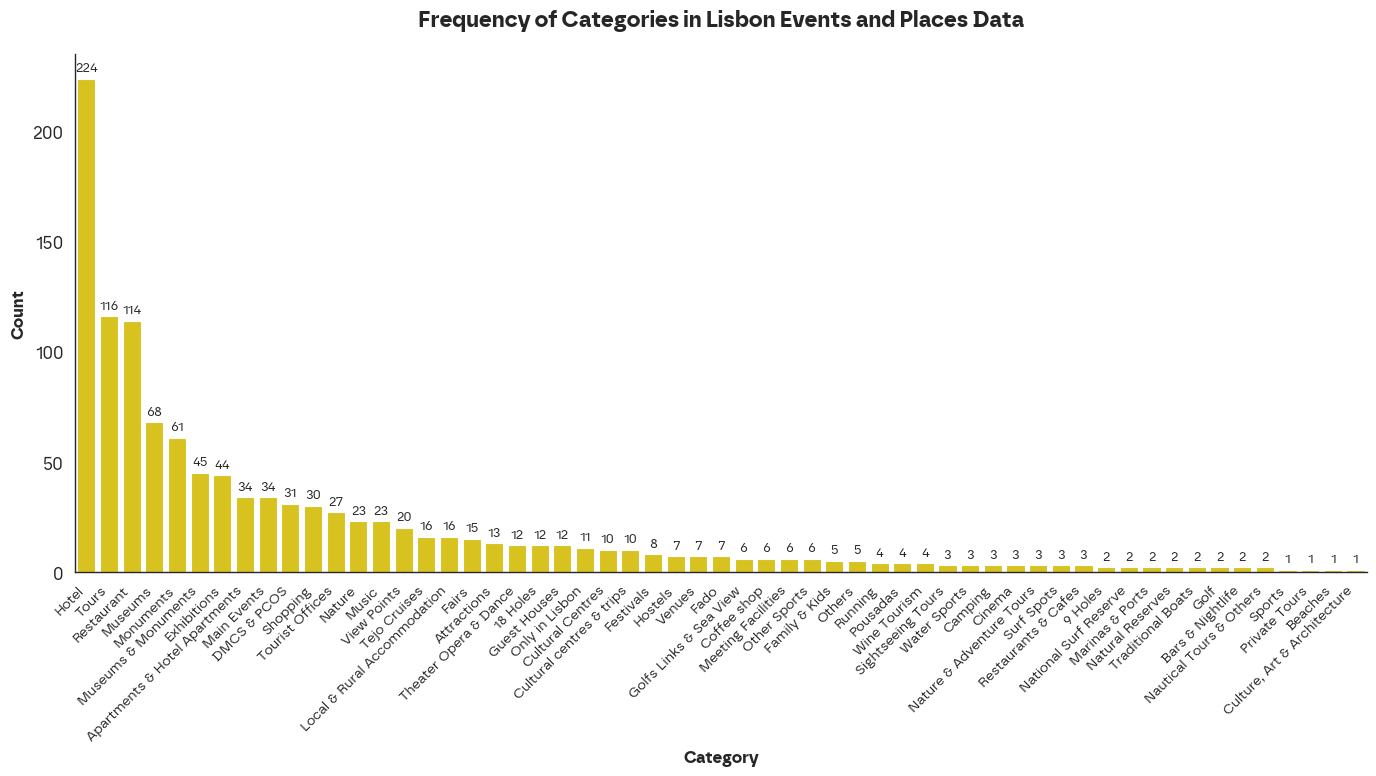

In [84]:
# Create a bar chart in yellow tones for Lisbon categories
plt.figure(figsize=(14, 8))

# Create barplot
ax = sns.barplot(data=combined_freq, x='Category', y='n', color=custom_palette[2])

# Customization
ax.set_title('Frequency of Categories in Lisbon Events and Places Data', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add value labels
for i in ax.containers:
    ax.bar_label(i, padding=3, fontsize=10)

# Remove spines
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()